<a href="https://colab.research.google.com/github/GimenesPaula/GimenesPaula/blob/main/Processamento_de_Imagem_Mecha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importar Bibliotecas
import cv2
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow
from google.colab import files, drive
from skimage.metrics import structural_similarity as compare_ssim
from PIL import Image
import matplotlib.pyplot as plt
import os

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Função para carregar imagens
def carregar_imagens():
    uploaded = files.upload()  # Permite ao usuário fazer upload de imagens
    imagens = []
    nomes = []
    for nome_arquivo in uploaded.keys():
        img = cv2.imread(nome_arquivo)
        if img is not None:
            imagens.append(img)
            nomes.append(nome_arquivo)
    return imagens, nomes

In [4]:
# Carregar imagens
imagens, nomes = carregar_imagens()

Saving 2.JPG to 2.JPG
Saving 3.JPG to 3.JPG
Saving 4.JPG to 4.JPG


In [5]:
# Função para exibir imagens em uma grade
def exibir_imagens_em_grade(imagens, titulos=None, max_colunas=4):
    num_imagens = len(imagens)
    num_linhas = -(-num_imagens // max_colunas)  # Calcula o número de linhas usando divisão inteira arredondada para cima

    plt.figure(figsize=(15, 5 * num_linhas))  # Ajusta o tamanho da figura

    for i, img in enumerate(imagens):
        plt.subplot(num_linhas, max_colunas, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Converte BGR para RGB
        if titulos:
            plt.title(titulos[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

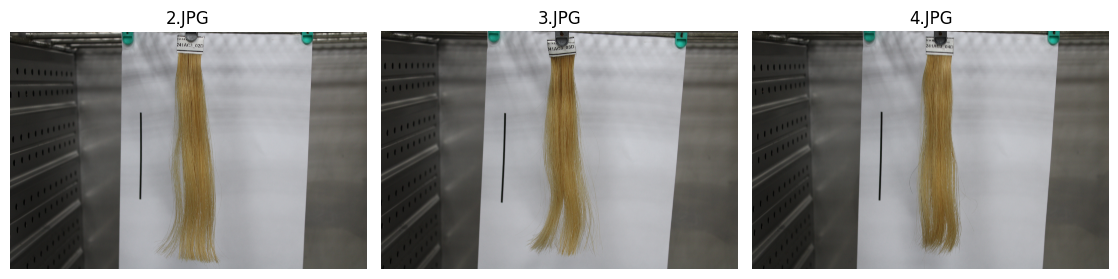

In [6]:
exibir_imagens_em_grade(imagens, nomes)

In [7]:
# Função para detectar a mecha de cabelo e calcular a área
def detectar_mecha_e_calcular_area(imagem):
    # Converter para o espaço de cores HSV
    hsv = cv2.cvtColor(imagem, cv2.COLOR_BGR2HSV)

    # Intervalos de cores para a mecha de cabelo
    intervalos = {
        "amarelo": (np.array([20, 50, 50]), np.array([40, 255, 255])),
        "castanho": (np.array([10, 20, 20]), np.array([20, 200, 200])),
        "ruivo": (np.array([0, 50, 50]), np.array([10, 255, 255]))  # Intervalo para cabelo ruivo
    }

    # Criar máscaras combinadas para amarelo, castanho e ruivo
    mask = sum(cv2.inRange(hsv, *intervalo) for intervalo in intervalos.values())

    # Operações morfológicas para limpar a máscara
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))  # Reduzir o kernel para capturar detalhes mais finos
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Encontrar contornos na máscara
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)  # Usar CHAIN_APPROX_NONE para mais detalhes

    if not contours:
        print("Nenhum contorno encontrado!")
        return imagem, None, 0, 0

    # Selecionar o maior contorno
    maior_contorno = max(contours, key=cv2.contourArea)
    area_mecha = cv2.contourArea(maior_contorno)

    # Desenhar o contorno na imagem
    imagem_com_contorno = imagem.copy()
    cv2.drawContours(imagem_com_contorno, [maior_contorno], -1, (0, 255, 0), 2)

    # Detectar a linha preta para calcular a área relativa
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 50]))
    contours_black, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours_black:
        print("Linha preta não encontrada!")
        return imagem_com_contorno, maior_contorno, area_mecha, 0

    # Selecionar o maior contorno da linha preta
    linha_preta = max(contours_black, key=cv2.contourArea)
    area_linha_preta = cv2.contourArea(linha_preta)

    # Calcular a área relativa
    area_relativa = area_mecha / area_linha_preta if area_linha_preta > 0 else 0

    return imagem_com_contorno, maior_contorno, area_mecha, area_relativa

In [8]:
# Função para exibir a área interna de um contorno, para montar a imagem e contorno sobrepostos
def exibir_area_interna(imagem, contorno):
    # Criar uma máscara vazia
    mask = np.zeros(imagem.shape[:2], dtype=np.uint8)

    # Preencher o contorno na máscara
    if contorno is not None:
        cv2.drawContours(mask, [contorno], -1, 255, thickness=cv2.FILLED)

    # Aplicar a máscara na imagem original
    area_interna = cv2.bitwise_and(imagem, imagem, mask=mask)
    return area_interna

In [12]:
def pre_processamento(imagem):
    # Converter para escala de cinza
    gray = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

    # Equalização do histograma para melhorar o contraste
    equalized = cv2.equalizeHist(gray)

    # Aplicar filtro Gaussiano para suavizar e reduzir ruídos
    blurred = cv2.GaussianBlur(equalized, (5, 5), 0)

    # Subtração de fundo para remover sombras
    background = cv2.medianBlur(blurred, 21)
    subtracted = cv2.absdiff(blurred, background)

    # Realçar os detalhes finos (cabelos mais finos e bordas inferiores)
    enhanced = cv2.addWeighted(equalized, 1.5, subtracted, -0.5, 0)

    # Converter a imagem realçada de volta para 3 canais para subtração com a imagem original
    enhanced_bgr = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)

    # Subtrair as correções da imagem original para preservar os detalhes do cabelo
#    corrected = cv2.subtract(imagem, enhanced_bgr)

    # Converter a imagem corrigida para o espaço de cores HSV
    hsv = cv2.cvtColor(corrected, cv2.COLOR_BGR2HSV)

    return hsv


In [10]:
# Processar cada imagem com pré-processamento e exibir etapas intermediárias
def processar_e_exibir_imagens(imagens, nomes, max_colunas=4):
    imagens_com_contorno = []
    imagens_preprocessadas = []
    titulos = []
    resultados = []  # Lista para armazenar os dados para o Excel

    for i, img in enumerate(imagens):
        # Pré-processar a imagem para reduzir sombras
        img_preprocessada = pre_processamento(img)

        # Detectar a mecha e calcular a área na imagem original
        imagem_original_com_contorno, _, area_original, area_relativa_original = detectar_mecha_e_calcular_area(img)

        # Detectar a mecha e calcular a área na imagem pré-processada
        # Aqui, usamos a imagem original para HSV, mas os contornos são baseados na imagem pré-processada
        imagem_processada_com_contorno, maior_contorno, area_processada, area_relativa_processada = detectar_mecha_e_calcular_area(img_preprocessada)

        # Desenhar o contorno detectado na imagem original
        if maior_contorno is not None:
            cv2.drawContours(imagem_processada_com_contorno, [maior_contorno], -1, (0, 255, 0), 2)

        # Adicionar as imagens com contornos à lista
        imagens_com_contorno.append(imagem_original_com_contorno)
        imagens_preprocessadas.append(imagem_processada_com_contorno)

        # Criar títulos para exibição
        titulos.append(f"{nomes[i]}\nÁrea Original: {area_original:.2f}\nÁrea Processada: {area_processada:.2f}")

        # Adicionar os resultados ao DataFrame
        resultados.append({
            "Nome": nomes[i],
            "Área Original": round(area_original, 2),
            "Área Relativa Original": round(area_relativa_original, 2),
            "Área Processada": round(area_processada, 2),
            "Área Relativa Processada": round(area_relativa_processada, 2)
        })

    # Criar um DataFrame do pandas com os resultados
    df = pd.DataFrame(resultados)

    # Salvar o DataFrame em um arquivo Excel
    df.to_excel("Resultado Frizz.xlsx", index=False)

    print("Resultados salvos no arquivo: 'Resultado Frizz.xlsx'")

    # Exibir todas as imagens pré-processadas em uma grade
    print("Imagens Pré-Processadas:")
    exibir_imagens_em_grade(imagens_preprocessadas, nomes, max_colunas)

    # Exibir todas as imagens com contornos em uma grade
    print("Imagens com Contornos (Original):")
    exibir_imagens_em_grade(imagens_com_contorno, titulos, max_colunas)


Nenhum contorno encontrado!
Nenhum contorno encontrado!
Resultados salvos no arquivo: 'Resultado Frizz.xlsx'
Imagens Pré-Processadas:


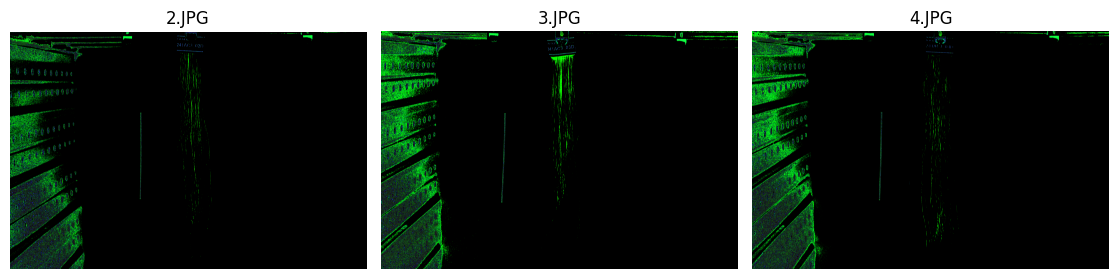

Imagens com Contornos (Original):


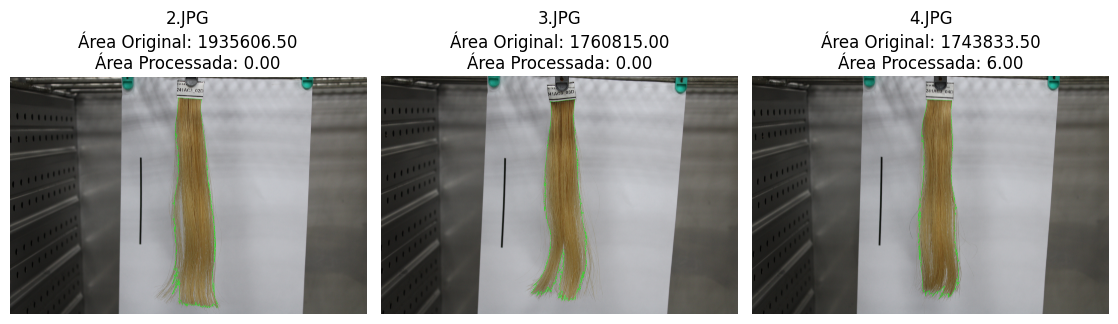

In [11]:
# Chamar a função para processar e exibir as imagens
processar_e_exibir_imagens(imagens, nomes)